In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed_data.csv")
print(df.shape)
df.head()

(1000, 25)


,record_id,workload_type,compute_demand_TFlops,storage_demand_TB,network_demand_Gbps,energy_source,energy_consumption_kWh,renewable_share_percent,carbon_emissions_kgCO2,qso_optimization_score,...,secure_operations_score,workload_scenario,scenario_strategy,operational_cost_usd,performance_metric,it_energy_kWh,PUE,co2_kg,is_zombie,workload_encoded
0,DC0001,Cloud Storage,408.32,62.95,67.84,Grid,14640.06,34.19,1113.58,0.555,...,0.874,Medium,Performance-Driven Strategy,194423.36,0.677,9711.831424,1.5074,12004.8492,0,1
1,DC0002,Cloud Storage,499.86,122.46,82.93,Wind,40116.37,27.88,310.16,0.902,...,0.879,Medium,Balanced Approach,21317.79,0.861,28081.459000,1.4286,32895.4234,0,1
2,DC0003,Database Queries,498.35,143.51,29.81,Hybrid,16986.44,32.22,1398.70,0.926,...,0.977,Low,Balanced Approach,180738.68,0.621,11880.245317,1.4298,13928.8808,0,2
3,DC0004,Cloud Storage,282.16,55.25,1.92,Hybrid,15669.79,37.58,1600.27,0.009,...,0.527,Medium,Balanced Approach,29590.03,0.725,9603.945513,1.6316,12849.2278,0,1
4,DC0005,Web Hosting,386.80,83.30,73.92,Hybrid,12392.79,59.96,368.54,0.075,...,0.798,Renewable Boost,Performance-Driven Strategy,81626.97,0.660,8114.344495,1.5273,10162.0878,0,4


In [2]:
df.describe()


,compute_demand_TFlops,storage_demand_TB,network_demand_Gbps,energy_consumption_kWh,renewable_share_percent,carbon_emissions_kgCO2,qso_optimization_score,uncertainty_factor,pqc_enabled,energy_efficiency_index,service_quality_index,secure_operations_score,operational_cost_usd,performance_metric,it_energy_kWh,PUE,co2_kg,is_zombie,workload_encoded
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,253.231160,100.609740,50.257720,24760.040100,54.762600,1023.278490,0.488369,0.483096,0.52000,0.748396,0.747026,0.755322,102458.843710,0.797341,14918.656502,1.678183,20303.232882,0.053000,2.060000
std,142.596825,57.154813,28.891489,13915.849584,25.847474,571.351923,0.284429,0.288045,0.49985,0.139075,0.143455,0.143130,58083.524322,0.115715,8575.618436,0.160674,11410.996659,0.224146,1.436824
min,12.270000,1.310000,0.500000,1001.510000,10.020000,57.640000,0.000000,0.000000,0.00000,0.500000,0.500000,0.501000,5030.760000,0.601000,585.165373,1.428600,821.238200,0.000000,0.000000
25%,125.362500,52.210000,25.262500,12609.617500,32.972500,515.975000,0.245750,0.230750,0.00000,0.634000,0.623000,0.635750,51675.820000,0.695000,7627.492545,1.538625,10339.886350,0.000000,1.000000
50%,253.870000,101.860000,50.825000,24603.545000,53.405000,1027.680000,0.481000,0.468000,1.00000,0.748500,0.747000,0.755500,99868.150000,0.795500,14545.264894,1.662300,20174.906900,0.000000,2.000000
75%,374.715000,149.517500,75.022500,36566.517500,77.485000,1529.842500,0.731750,0.725500,1.00000,0.862250,0.871000,0.879000,155918.282500,0.894250,21975.235284,1.817675,29984.544350,0.000000,3.000000
max,499.860000,199.670000,99.890000,49978.330000,99.890000,1998.950000,0.999000,0.997000,1.00000,0.999000,1.000000,1.000000,199756.260000,1.000000,34386.232534,1.980600,40982.230600,1.000000,4.000000


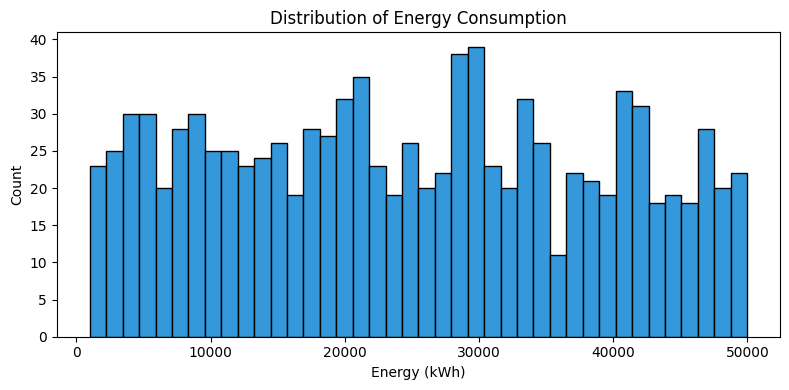

In [3]:

plt.figure(figsize=(8, 4))
plt.hist(df["energy_consumption_kWh"], bins=40, color="#3498db", edgecolor="black")
plt.title("Distribution of Energy Consumption")
plt.xlabel("Energy (kWh)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

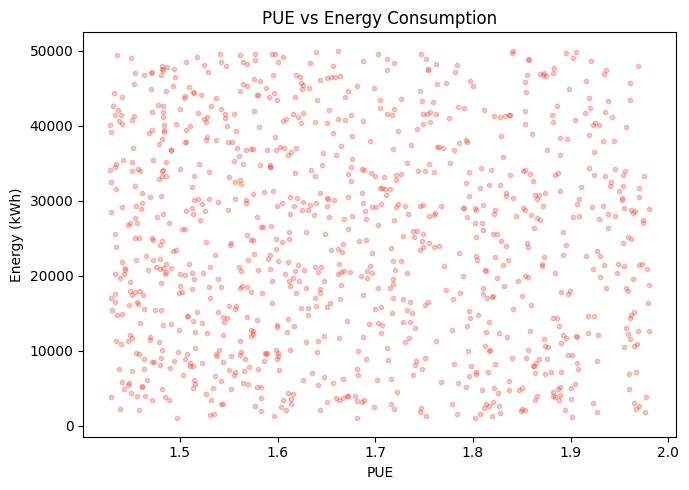

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(df["PUE"], df["energy_consumption_kWh"],
            alpha=0.3, color="#e74c3c", s=10)
plt.title("PUE vs Energy Consumption")
plt.xlabel("PUE")
plt.ylabel("Energy (kWh)")
plt.tight_layout()
plt.show()

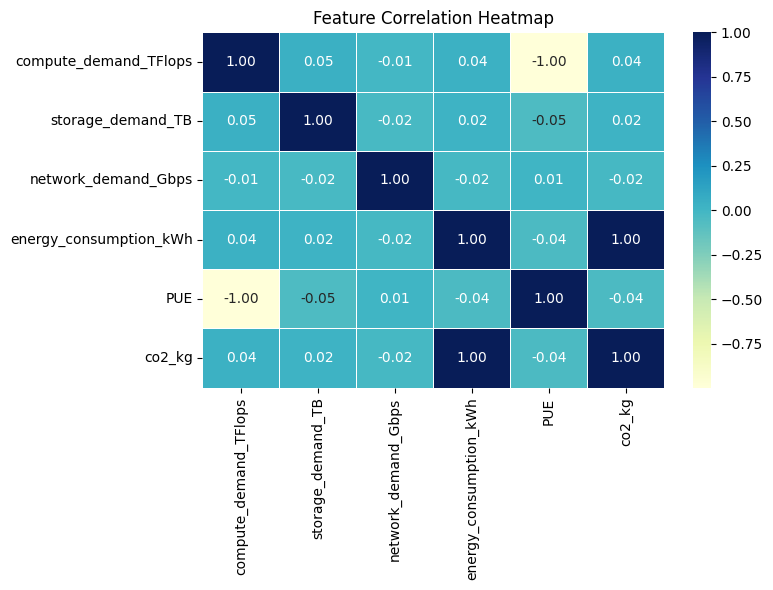

In [5]:

cols = ["compute_demand_TFlops", "storage_demand_TB",
        "network_demand_Gbps",   "energy_consumption_kWh",
        "PUE", "co2_kg"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f",
            cmap="YlGnBu", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

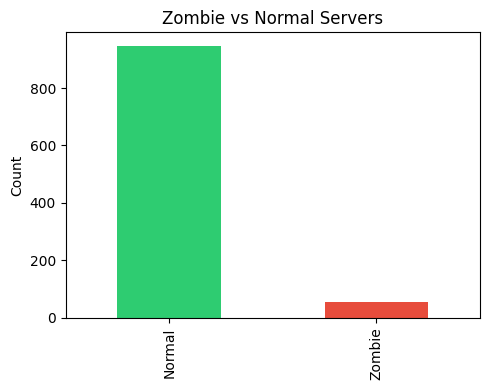

In [6]:

zombie_counts = df["is_zombie"].value_counts()
zombie_counts.index = ["Normal", "Zombie"]
zombie_counts.plot(kind="bar", color=["#2ecc71", "#e74c3c"],
                   title="Zombie vs Normal Servers", figsize=(5, 4))
plt.ylabel("Count")
plt.tight_layout()
plt.show()